In [21]:
# Importar librerías
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, min as spark_min,
    max as spark_max, stddev, isnan, when, isnull, desc
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Configurar SparkSession
spark = SparkSession.builder \
    .appName("SECOP_EDA") \
    .master("spark://spark-master:7077") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print(f"Spark Master: {spark.sparkContext.master}")

Spark Version: 3.5.0
Spark Master: spark://spark-master:7077


In [23]:
# Cargar datos desde Parquet
parquet_path = "/opt/spark-data/processed/secop_contratos_silver.parquet"
print(f"Cargando datos desde: {parquet_path}")

Cargando datos desde: /opt/spark-data/processed/secop_contratos_silver.parquet


In [24]:
df = spark.read.parquet(parquet_path)
print(f"Registros cargados: {df.count():,}")
print(f"Columnas: {len(df.columns)}")

Registros cargados: 100,000
Columnas: 13


In [25]:
# Mostrar esquema
print("\n=== ESQUEMA DEL DATASET ===")
df.printSchema()


=== ESQUEMA DEL DATASET ===
root
 |-- referencia_del_contrato: string (nullable = true)
 |-- nit_entidad: string (nullable = true)
 |-- nombre_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- valor_del_contrato: double (nullable = true)
 |-- fecha_de_firma: timestamp (nullable = true)
 |-- duraci_n_del_contrato: integer (nullable = true)
 |-- proveedor_adjudicado: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



In [26]:
# Primeras filas
print("\n=== PRIMERAS 10 FILAS ===")
df.show(10, truncate=True)
# Estadísticas descriptivas generales
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().show()


=== PRIMERAS 10 FILAS ===


+-----------------------+-----------+--------------------+--------------------+-----------+--------------------+------------------+-------------------+---------------------+--------------------+---------------+----+-----+
|referencia_del_contrato|nit_entidad|      nombre_entidad|        departamento|     ciudad|    tipo_de_contrato|valor_del_contrato|     fecha_de_firma|duraci_n_del_contrato|proveedor_adjudicado|estado_contrato|year|month|
+-----------------------+-----------+--------------------+--------------------+-----------+--------------------+------------------+-------------------+---------------------+--------------------+---------------+----+-----+
|        RSC-CD-144-2025| 8440041972|RED SALUD CASANAR...|            Casanare|      Yopal|Prestación de ser...|           2.067E7|2025-01-14 00:00:00|                 NULL|LUIS LEONIDAS ROD...|     Modificado|2025|    1|
|            05000992025|  899999239|ICBF REGIONAL ANT...|           Antioquia|   Medellín|Prestación de ser...|

+-------+-----------------------+--------------------+--------------------+------------+---------+--------------------+--------------------+---------------------+--------------------+---------------+------+------+
|summary|referencia_del_contrato|         nit_entidad|      nombre_entidad|departamento|   ciudad|    tipo_de_contrato|  valor_del_contrato|duraci_n_del_contrato|proveedor_adjudicado|estado_contrato|  year| month|
+-------+-----------------------+--------------------+--------------------+------------+---------+--------------------+--------------------+---------------------+--------------------+---------------+------+------+
|  count|                 100000|              100000|              100000|      100000|   100000|              100000|              100000|                    0|              100000|         100000|100000|100000|
|   mean|   1.401807708882322...|  1.57489914174078E9|                NULL|        NULL|     NULL|                NULL|   1.0809235143475E8|    

In [27]:
# Análisis de valores nulos por columna
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType

print("\n=== ANÁLISIS DE VALORES NULOS ===")


=== ANÁLISIS DE VALORES NULOS ===


In [28]:
numeric_types = (DoubleType, IntegerType, FloatType, LongType)

expressions = []

for c in df.columns:
    if isinstance(df.schema[c].dataType, numeric_types):
        expr = count(when(isnull(col(c)) | isnan(col(c)), c)).alias(c)
    else:
        expr = count(when(isnull(col(c)), c)).alias(c)
    
    expressions.append(expr)

null_counts = df.select(expressions)

null_df = null_counts.toPandas().T
null_df.columns = ['null_count']
null_df['null_percentage'] = (null_df['null_count'] / df.count()) * 100
null_df = null_df.sort_values('null_count', ascending=False)

print(null_df[null_df['null_count'] > 0])

                       null_count  null_percentage
duraci_n_del_contrato      100000            100.0


In [29]:
# Convertir a pandas para mejor visualización
null_df = null_counts.toPandas().T
null_df.columns = ['null_count']
null_df['null_percentage'] = (null_df['null_count'] / df.count()) * 100
null_df = null_df.sort_values('null_count', ascending=False)

print(null_df[null_df['null_count'] > 0])
# Análisis de la variable objetivo: Valor del Contrato
# Nota: Ajustar nombre de columna según dataset real

                       null_count  null_percentage
duraci_n_del_contrato      100000            100.0


In [30]:
# Identificar columna de valor (puede variar)
valor_cols = [c for c in df.columns if 'valor' in c.lower() or 'precio' in c.lower()]
print(f"\n=== COLUMNAS DE VALOR ENCONTRADAS ===")
for col_name in valor_cols:
    print(f"- {col_name}")
# Usar la primera columna de valor encontrada
if valor_cols:
    valor_col = valor_cols[0]
    print(f"\nUsando columna: {valor_col}")


=== COLUMNAS DE VALOR ENCONTRADAS ===
- valor_del_contrato

Usando columna: valor_del_contrato


In [31]:
# Convertir a numérico si es string
df = df.withColumn(valor_col + "_num", col(valor_col).cast("double"))

In [32]:
# Estadísticas de valor del contrato
print(f"\n=== ESTADÍSTICAS: {valor_col} ===")
df.select(
spark_min(col(valor_col + "_num")).alias("Min"),
spark_max(col(valor_col + "_num")).alias("Max"),
avg(col(valor_col + "_num")).alias("Promedio"),
stddev(col(valor_col + "_num")).alias("Desv_Std")
).show()


=== ESTADÍSTICAS: valor_del_contrato ===
+---+----------------+-----------------+--------------------+
|Min|             Max|         Promedio|            Desv_Std|
+---+----------------+-----------------+--------------------+
|0.0|4.08987300811E11|1.0809235143475E8|2.4064589461934705E9|
+---+----------------+-----------------+--------------------+



In [33]:
# Usar la primera columna de valor encontrada
if valor_cols:
    valor_col = valor_cols[0]
    print(f"\nUsando columna: {valor_col}")


Usando columna: valor_del_contrato


In [34]:
# Convertir a numérico si es string
df = df.withColumn(valor_col + "_num", col(valor_col).cast("double"))

In [35]:
# Estadísticas de valor del contrato
print(f"\n=== ESTADÍSTICAS: {valor_col} ===")
df.select(
        spark_min(col(valor_col + "_num")).alias("Min"),
        spark_max(col(valor_col + "_num")).alias("Max"),
        avg(col(valor_col + "_num")).alias("Promedio"),
        stddev(col(valor_col + "_num")).alias("Desv_Std")
).show()


=== ESTADÍSTICAS: valor_del_contrato ===
+---+----------------+-----------------+--------------------+
|Min|             Max|         Promedio|            Desv_Std|
+---+----------------+-----------------+--------------------+
|0.0|4.08987300811E11|1.0809235143475E8|2.4064589461934705E9|
+---+----------------+-----------------+--------------------+



In [36]:
# Análisis por Departamento
dept_cols = [c for c in df.columns if 'departamento' in c.lower()]
if dept_cols:
    dept_col = dept_cols[0]
    print(f"\n=== TOP 10 DEPARTAMENTOS POR NÚMERO DE CONTRATOS ===")

    df_dept = df.groupBy(dept_col) \
        .agg(
            count("*").alias("num_contratos"),
            spark_sum(col(valor_col + "_num")).alias("valor_total") if valor_cols else count("*").alias("valor_total")
        ) \
        .orderBy(desc("num_contratos")) \
        .limit(10)

    df_dept.show(truncate=False)


=== TOP 10 DEPARTAMENTOS POR NÚMERO DE CONTRATOS ===


+--------------------------+-------------+-----------------+
|departamento              |num_contratos|valor_total      |
+--------------------------+-------------+-----------------+
|Distrito Capital de Bogotá|34342        |3.583334435156E12|
|Antioquia                 |15200        |2.750915522514E12|
|Valle del Cauca           |11391        |4.42495017558E11 |
|Cundinamarca              |6463         |3.37096707027E11 |
|Boyacá                    |3119         |4.10357352292E11 |
|Santander                 |2465         |1.00798367591E11 |
|Nariño                    |2354         |8.1654885059E10  |
|Magdalena                 |2313         |2.16586924675E11 |
|Meta                      |2095         |1.33345860387E11 |
|Caldas                    |1978         |2.44375876417E11 |
+--------------------------+-------------+-----------------+



In [37]:
# Convertir a pandas para visualización
df_dept_pandas = df_dept.toPandas()


Gráfico guardado: /opt/spark-data/processed/eda_departamentos.png


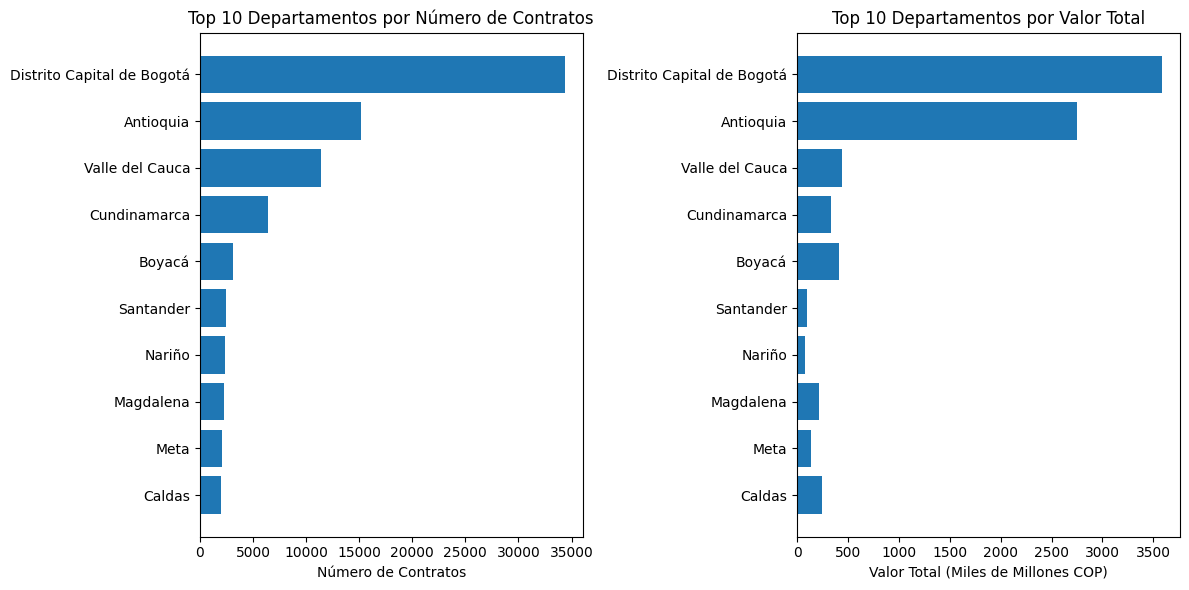

In [38]:
# Visualización

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(df_dept_pandas[dept_col], df_dept_pandas['num_contratos'])
plt.xlabel('Número de Contratos')
plt.title('Top 10 Departamentos por Número de Contratos')
plt.gca().invert_yaxis()

if valor_cols:
    plt.subplot(1, 2, 2)
    plt.barh(df_dept_pandas[dept_col], df_dept_pandas['valor_total'] / 1e9)
    plt.xlabel('Valor Total (Miles de Millones COP)')
    plt.title('Top 10 Departamentos por Valor Total')
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('/opt/spark-data/processed/eda_departamentos.png', dpi=150, bbox_inches='tight')
print("\nGráfico guardado: /opt/spark-data/processed/eda_departamentos.png")

In [39]:
# %%
# Análisis por Tipo de Contrato
tipo_cols = [c for c in df.columns if 'tipo' in c.lower() and 'contrato' in c.lower()]
if tipo_cols:
    tipo_col = tipo_cols[0]
    print(f"\n=== DISTRIBUCIÓN POR TIPO DE CONTRATO ===")

    df_tipo = df.groupBy(tipo_col) \
        .agg(count("*").alias("num_contratos")) \
        .orderBy(desc("num_contratos")) \
        .limit(10)

    df_tipo.show(truncate=False)



=== DISTRIBUCIÓN POR TIPO DE CONTRATO ===
+--------------------------+-------------+
|tipo_de_contrato          |num_contratos|
+--------------------------+-------------+
|Prestación de servicios   |94836        |
|Decreto 092 de 2017       |3089         |
|Otro                      |764          |
|Arrendamiento de inmuebles|587          |
|Suministros               |415          |
|Obra                      |63           |
|Comodato                  |45           |
|Compraventa               |41           |
|Arrendamiento de muebles  |40           |
|Seguros                   |39           |
+--------------------------+-------------+



In [40]:
# %%
# Análisis por Estado del Contrato
estado_cols = [c for c in df.columns if 'estado' in c.lower()]
if estado_cols:
    estado_col = estado_cols[0]
    print(f"\n=== DISTRIBUCIÓN POR ESTADO DE CONTRATO ===")

    df_estado = df.groupBy(estado_col) \
        .agg(count("*").alias("num_contratos")) \
        .orderBy(desc("num_contratos"))

    df_estado.show(truncate=False)


=== DISTRIBUCIÓN POR ESTADO DE CONTRATO ===
+---------------+-------------+
|estado_contrato|num_contratos|
+---------------+-------------+
|En ejecución   |40896        |
|Modificado     |34492        |
|terminado      |11621        |
|Cerrado        |11068        |
|cedido         |1217         |
|Aprobado       |618          |
|Suspendido     |88           |
+---------------+-------------+



In [41]:
# %%
# Análisis de Top Proveedores
proveedor_cols = [c for c in df.columns if 'proveedor' in c.lower()]
if proveedor_cols:
    proveedor_col = proveedor_cols[0]
    print(f"\n=== TOP 10 PROVEEDORES ===")

    df_prov = df.groupBy(proveedor_col) \
        .agg(
            count("*").alias("num_contratos"),
            spark_sum(col(valor_col + "_num")).alias("valor_total") if valor_cols else count("*").alias("valor_total")
        ) \
        .orderBy(desc("num_contratos")) \
        .limit(10)

    df_prov.show(truncate=False)


=== TOP 10 PROVEEDORES ===


+------------------------------------------------------+-------------+----------------+
|proveedor_adjudicado                                  |num_contratos|valor_total     |
+------------------------------------------------------+-------------+----------------+
|Sin Descripcion                                       |32           |2.692830378E9   |
|COHOSAN                                               |22           |3.250596836E9   |
|Persona natural                                       |21           |4.79600857E8    |
|CARLOS ALBERTO RIVERA ESCOBAR                         |20           |8.1156E7        |
|Aseguradora Solidaria de Colombia Entidad Cooperativa.|20           |1.083325605E9   |
|FUNDACION Y BCO DE ALIMENTOS CENTRAL MAYORISTA        |20           |3.047984646E10  |
|INDER ENVIGADO1                                       |19           |2.34205222292E11|
|ITM                                                   |18           |9.1696141E7     |
|Fundacion Pascual Bravo        

In [42]:
# %%
# Detección de Outliers en Valor del Contrato
if valor_cols:
    print(f"\n=== DETECCIÓN DE OUTLIERS ===")

    # Calcular percentiles
    percentiles = df.approxQuantile(valor_col + "_num", [0.25, 0.50, 0.75, 0.95, 0.99], 0.01)

    print(f"Q1 (25%): ${percentiles[0]:,.2f}")
    print(f"Q2 (50%): ${percentiles[1]:,.2f}")
    print(f"Q3 (75%): ${percentiles[2]:,.2f}")
    print(f"P95 (95%): ${percentiles[3]:,.2f}")
    print(f"P99 (99%): ${percentiles[4]:,.2f}")

    # IQR method
    q1, q3 = percentiles[0], percentiles[2]
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"\nRango normal (IQR): ${lower_bound:,.2f} - ${upper_bound:,.2f}")

    # Contar outliers
    num_outliers = df.filter(
        (col(valor_col + "_num") < lower_bound) |
        (col(valor_col + "_num") > upper_bound)
    ).count()

    print(f"Outliers detectados: {num_outliers:,} ({(num_outliers/df.count())*100:.2f}%)")


=== DETECCIÓN DE OUTLIERS ===


Q1 (25%): $16,800,000.00
Q2 (50%): $31,549,600.00
Q3 (75%): $56,826,002.00
P95 (95%): $124,372,000.00
P99 (99%): $408,987,300,811.00

Rango normal (IQR): $-43,239,003.00 - $116,865,005.00


Outliers detectados: 6,761 (6.76%)


In [43]:
# %%
# Análisis temporal (si hay columna de fecha)
fecha_cols = [c for c in df.columns if 'fecha' in c.lower()]
if fecha_cols:
    fecha_col = fecha_cols[0]
    print(f"\n=== ANÁLISIS TEMPORAL ===")
    print(f"Columna de fecha: {fecha_col}")

    # Convertir a fecha
    from pyspark.sql.functions import to_date, year, month

    df = df.withColumn(fecha_col + "_parsed", to_date(col(fecha_col)))
    df = df.withColumn("anio", year(col(fecha_col + "_parsed")))
    df = df.withColumn("mes", month(col(fecha_col + "_parsed")))

    # Contratos por año
    print("\n=== CONTRATOS POR AÑO ===")
    df.groupBy("anio") \
        .agg(count("*").alias("num_contratos")) \
        .orderBy("anio") \
        .show()


=== ANÁLISIS TEMPORAL ===
Columna de fecha: fecha_de_firma

=== CONTRATOS POR AÑO ===


+----+-------------+
|anio|num_contratos|
+----+-------------+
|2025|       100000|
+----+-------------+



In [44]:
# %%
# Resumen final del EDA
print("\n" + "="*60)
print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*60)
print(f"✓ Total de registros analizados: {df.count():,}")
print(f"✓ Columnas analizadas: {len(df.columns)}")
if valor_cols:
    total_valor = df.select(spark_sum(col(valor_col + "_num"))).collect()[0][0]
    if total_valor:
        print(f"✓ Valor total de contratos: ${total_valor:,.2f}")
print(f"✓ Análisis por departamento: Completado")
print(f"✓ Análisis de outliers: Completado")
print(f"✓ Gráficos generados: /opt/spark-data/processed/")
print("="*60)


RESUMEN DEL ANÁLISIS EXPLORATORIO
✓ Total de registros analizados: 100,000
✓ Columnas analizadas: 17
✓ Valor total de contratos: $10,809,235,143,475.00
✓ Análisis por departamento: Completado
✓ Análisis de outliers: Completado
✓ Gráficos generados: /opt/spark-data/processed/


In [45]:
# Guardar dataset limpio para próximos notebooks
output_path = "/opt/spark-data/processed/secop_eda.parquet"
df.write.mode("overwrite").parquet(output_path)
print(f"\nDataset guardado en: {output_path}")


Dataset guardado en: /opt/spark-data/processed/secop_eda.parquet


In [46]:
# Detener SparkSession
spark.stop()
print("SparkSession finalizada")

SparkSession finalizada
